# OSM Point Features - Milan

Downloads traffic signals, public transport stops and amenity POIs from OSM for Milan,
counts them within a 50 m buffer of each street segment, normalizes by segment length
and exports `data/osm_points_features.csv`.
Roads loaded from `../layers/MIL_noise_streets.gpkg`.

In [1]:
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt
import pandas as pd

## Load roads

In [2]:
osm_roads = gpd.read_file("../layers/MIL_noise_streets.gpkg")
print(osm_roads.crs)
print(osm_roads.shape)
print(osm_roads.columns.tolist())
print("Number of street segments:", len(osm_roads))

C:\Users\giofo\miniconda3\envs\data-encoding\Lib\site-packages\pyogrio\core.py:34: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


EPSG:32632
(22164, 12)
['segment_id', 'highway', 'name', 'length', 'CLASSE_ACU', 'db_diurno', 'db_notturno', 'noise_day', 'noise_evening', 'noise_night', 'distance', 'geometry']
Number of street segments: 22164


## Traffic signals

In [3]:
signals = ox.features_from_place("Milan, Italy", tags={"highway": "traffic_signals"})
signals = signals[signals.geometry.type == 'Point'].to_crs(osm_roads.crs)
print(signals.crs)
print(signals.columns.tolist())

EPSG:32632
['geometry', 'highway', 'traffic_signals', 'junction', 'traffic_signals:direction', 'created_by', 'crossing', 'survey:date', 'bicycle', 'fixme', 'barrier', 'kerb', 'tactile_paving', 'crossing_ref', 'supervised', 'direction', 'crossing:barrier', 'railway', 'button_operated', 'traffic_signals:sound', 'traffic_signals:vibration', 'mapillary', 'wheelchair', 'note:it', 'image', 'crossing:island', 'source', 'start_date', 'foot', 'comment:it', 'obstacle:wheelchair', 'support', 'width', 'horse', 'stop', 'traffic_signals:countdown']


In [4]:
print(f"Total signals: {len(signals)}")
if 'traffic_signals' in signals.columns:
    print(f"Non-null traffic_signals: {signals['traffic_signals'].notna().sum()}")
    print(f"Null traffic_signals: {signals['traffic_signals'].isna().sum()}")
    print("\nValue counts:")
    print(signals['traffic_signals'].value_counts(dropna=False))

Total signals: 3058
Non-null traffic_signals: 1817
Null traffic_signals: 1241

Value counts:
traffic_signals
signal                 1632
NaN                    1241
traffic_lights          176
emergency                 4
pedestrian_crossing       2
blinker                   2
blink_mode                1
Name: count, dtype: int64


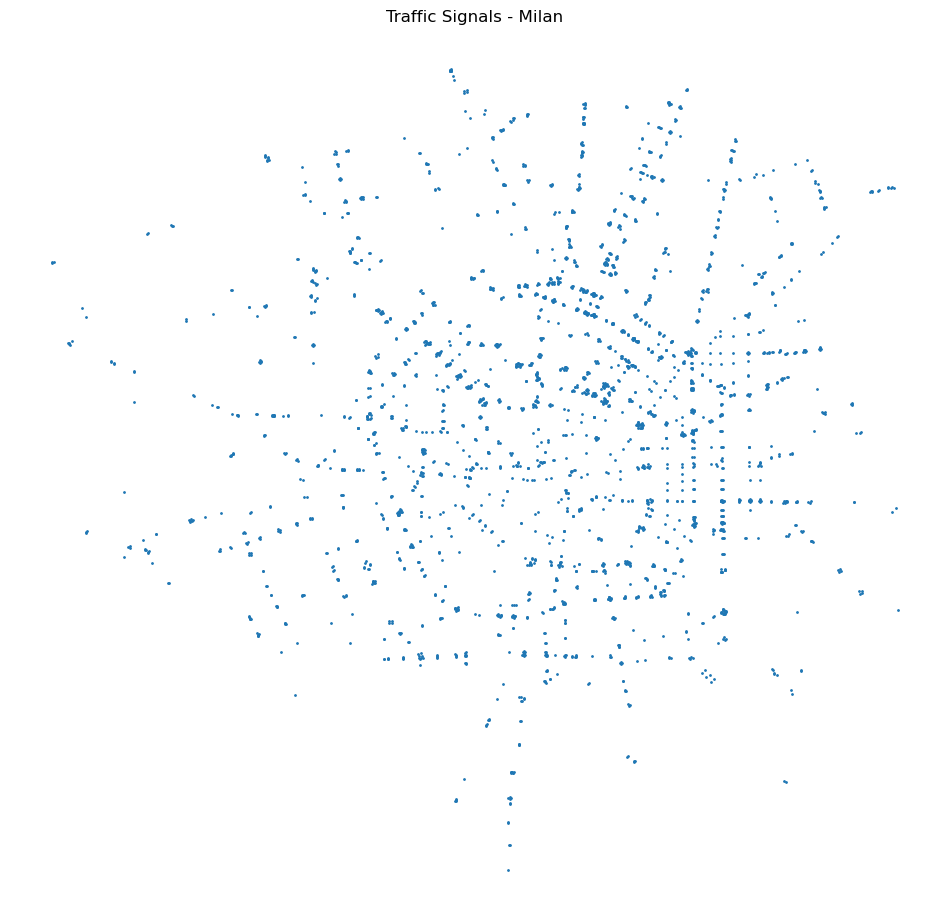

In [5]:
ax = signals.plot(markersize=1, figsize=(12, 12))
ax.set_title('Traffic Signals - Milan')
ax.set_axis_off()

## Public transport stops

In [6]:
transport = ox.features_from_place(
    "Milan, Italy",
    tags={"railway": ["station", "tram_stop", "subway_entrance"],
          "highway": "bus_stop"})
transport = transport[transport.geometry.type == 'Point'].to_crs(osm_roads.crs)
if 'railway' in transport.columns:
    transport['transport_type'] = transport['railway'].fillna(
        transport['highway'] if 'highway' in transport.columns else None
    )
elif 'highway' in transport.columns:
    transport['transport_type'] = transport['highway']
else:
    transport['transport_type'] = 'unknown'
print(transport.crs)
print(transport.columns.tolist())

EPSG:32632
['geometry', 'description', 'level', 'name', 'network', 'network:wikidata', 'official_name', 'operator', 'operator:wikidata', 'platforms', 'public_transport', 'railway', 'short_name', 'train', 'wheelchair', 'wikidata', 'wikipedia', 'bench', 'bin', 'bus', 'check_date:shelter', 'highway', 'lit', 'passenger_information_display', 'ref', 'shelter', 'tactile_paving', 'tram', 'operator:short', 'wikimedia_commons', 'internet_access', 'check_date', 'check_date:bench', 'check_date:bin', 'check_date:tactile_paving', 'mapillary', 'old_name', 'pole', 'towards', 'trolleybus', 'check_date:lit', 'survey:date', 'name:it', 'name:ja', 'start_date', 'departures_board', 'covered', 'bus_routes', 'station', 'subway', 'alt_name', 'route_ref', 'note', 'source', 'uic_ref', 'local_ref', 'comment:it', 'ele', 'fixme', 'comment:en', 'end_date', 'comment', 'ref_route', 'flag', 'platform_lift', 'check_date:wheelchair', 'door', 'entrance', 'disused:highway', 'disused:name', 'disused:passenger_information_di

In [7]:
print(f"Total transport points: {len(transport)}")
print(f"Non-null transport points: {transport['transport_type'].notna().sum()}")
print(f"Null transport points: {transport['transport_type'].isna().sum()}")
print("\nValue counts:")
print(transport['transport_type'].value_counts(dropna=False))

Total transport points: 4381
Non-null transport points: 4381
Null transport points: 0

Value counts:
transport_type
bus_stop           2754
tram_stop           787
subway_entrance     703
station             137
Name: count, dtype: int64


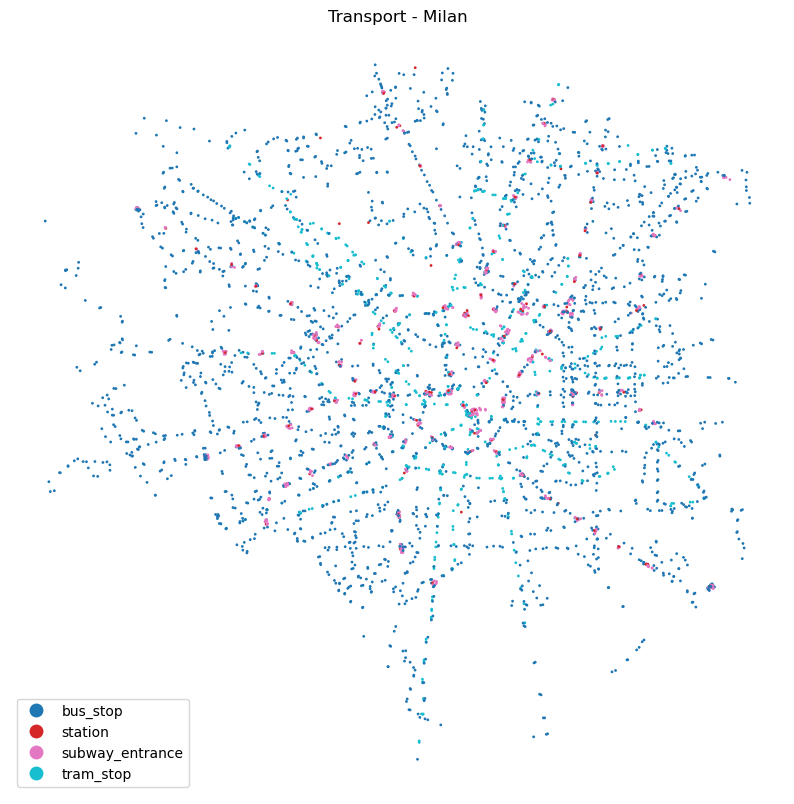

In [8]:
ax = transport.plot(column='transport_type', legend=True, markersize=1, figsize=(10, 10))
ax.set_title('Transport - Milan')
ax.set_axis_off()

## POIs (amenities)

In [9]:
pois = ox.features_from_place(
    "Milan, Italy",
    tags={"amenity": True}
)
pois = pois[pois.geometry.type == 'Point'].to_crs(osm_roads.crs)
print(pois.crs)
print(pois.columns.tolist())

EPSG:32632
['geometry', 'amenity', 'name', 'religion', 'brand', 'brand:wikidata', 'brand:wikipedia', 'operator', 'ref:mise', 'self_service', 'created_by', 'atm', 'addr:city', 'addr:housenumber', 'addr:postcode', 'addr:street', 'healthcare', 'healthcare:speciality', 'wheelchair', 'brand:en', 'brand:it', 'name:en', 'name:it', 'branch', 'phone', 'screen', 'website', 'wikidata', 'fuel:diesel', 'fuel:octane_95', 'dispensing', 'ref:msal', 'ref:vatin', 'source', 'contact:facebook', 'contact:instagram', 'drive_through', 'email', 'fax', 'opening_hours', 'fuel:lpg', 'compressed_air', 'fuel:cng', 'addr:country', 'check_date', 'description', 'payment:cash', 'payment:credit_cards', 'payment:debit_cards', 'fixme', 'payment:mastercard', 'payment:visa', 'nobrand', 'check_date:compressed_air', 'fuel:GTL_diesel', 'full_service', 'fuel:octane_100', 'toilets', 'fuel:octane_98', 'ref', 'ref:tamoil', 'payment:dkv', 'operator:wikidata', 'operator:wikipedia', 'operator:type', 'parking', 'phone:it', 'denominat

## Filter POI categories

In [10]:
filtered_categories = ['restaurant', 'cafe', 'bar', 'pub', 'nightclub', 'fast_food', 'food_court',
                        'music_venue', 'cinema', 'theatre', 'shopping_mall', 'shop', 'supermarket', 'marketplace']
pois_filtered = pois[pois['amenity'].isin(filtered_categories)]

traffic_categories = ['taxi']
pois_traffic = pois[pois['amenity'].isin(traffic_categories)]

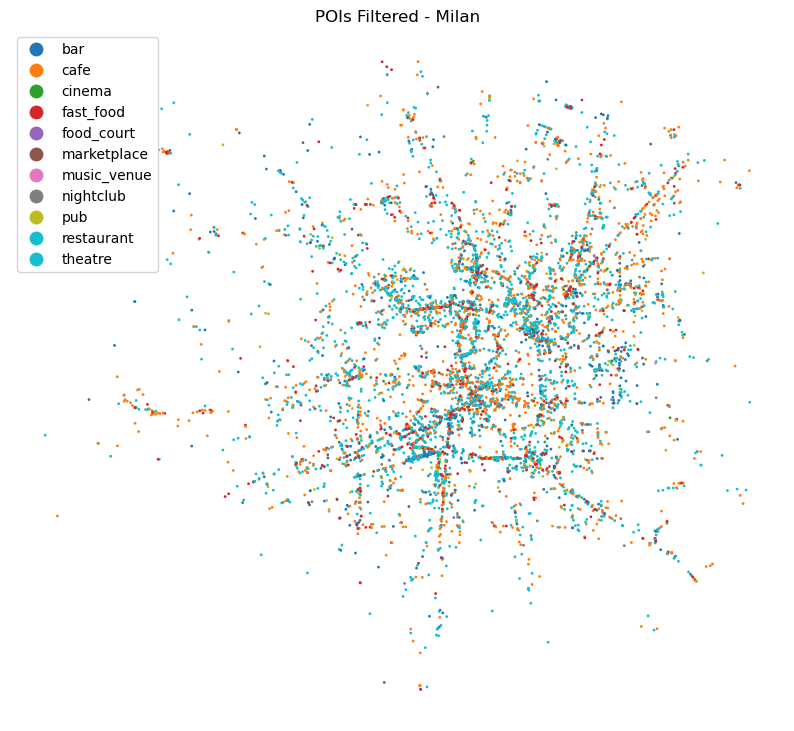

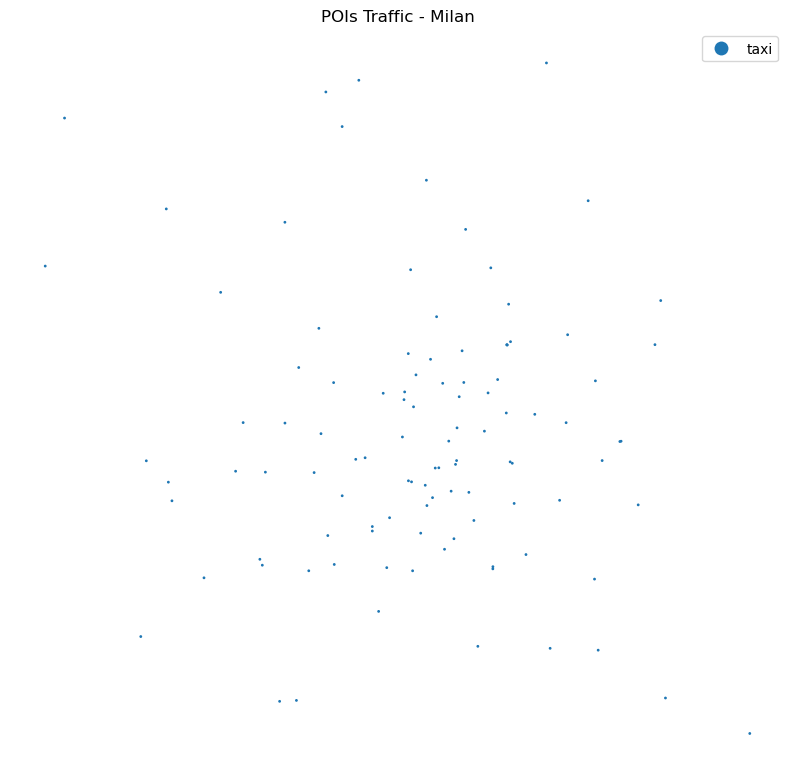

In [11]:
ax = pois_filtered.plot(figsize=(10, 10), column='amenity', legend=True, markersize=1)
ax.set_title('POIs Filtered - Milan')
ax.set_axis_off()

ax = pois_traffic.plot(figsize=(10, 10), column='amenity', legend=True, markersize=1)
ax.set_title('POIs Traffic - Milan')
ax.set_axis_off()

## Buffer streets by 50 m

In [12]:
buffered_50 = osm_roads.copy()
buffered_50['geometry'] = buffered_50.geometry.buffer(50)

## Count traffic signals per segment

In [13]:
signals_join = gpd.sjoin(signals, buffered_50, how="left", predicate="within")
signals_count = signals_join.groupby('index_right').size().rename('signal_count')

In [14]:
osm_roads_sig = osm_roads.join(signals_count)
osm_roads_sig['signal_count'] = osm_roads_sig['signal_count'].fillna(0) / osm_roads_sig['length']
q90 = osm_roads_sig['signal_count'].quantile(0.90)
osm_roads_sig['signal_count'] = osm_roads_sig['signal_count'].clip(upper=q90)
osm_roads_sig['signal_count'].describe()

count    22164.000000
mean         0.028097
std          0.046623
min          0.000000
25%          0.000000
50%          0.000000
75%          0.035143
max          0.139212
Name: signal_count, dtype: float64

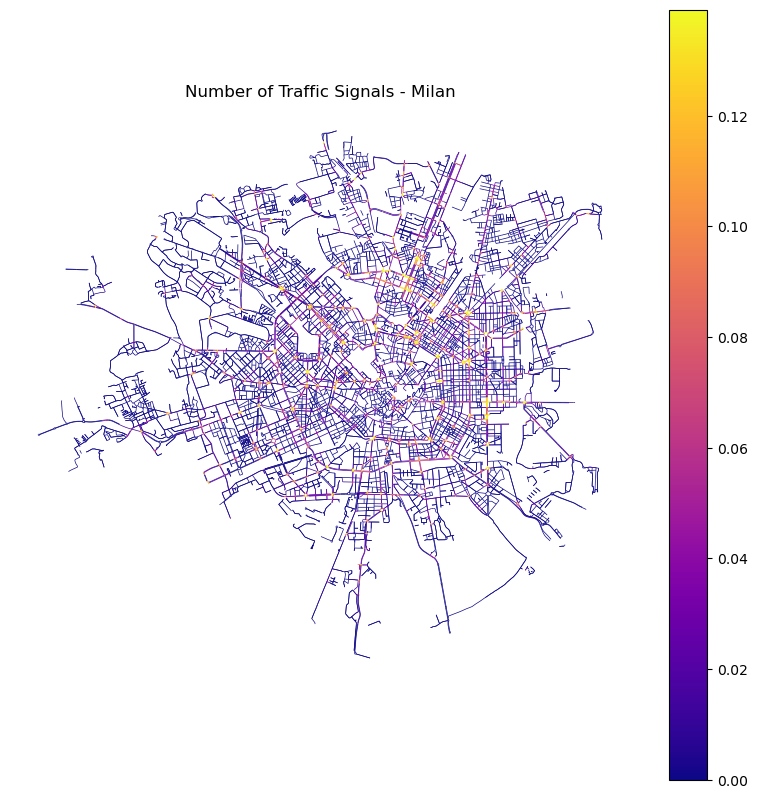

In [15]:
ax = osm_roads_sig.plot(column='signal_count', cmap='plasma', linewidth=0.5, legend=True, figsize=(10, 10))
ax.set_title('Number of Traffic Signals - Milan')
ax.set_axis_off()

## Count transport stops per segment

In [16]:
transport_join = gpd.sjoin(transport, buffered_50, how="left", predicate="within")
transport_count = transport_join.groupby('index_right').size().rename('transport_count')

traffic_join = gpd.sjoin(pois_traffic, buffered_50, how="left", predicate="within")
traffic_count = traffic_join.groupby('index_right').size().rename('traffic_count')

In [17]:
osm_roads_transport = osm_roads.join(transport_count)
osm_roads_transport = osm_roads_transport.join(traffic_count)
osm_roads_transport['transport_count'] = (
    osm_roads_transport['transport_count'].fillna(0) +
    osm_roads_transport['traffic_count'].fillna(0)
) / osm_roads_transport['length']
q90 = osm_roads_transport['transport_count'].quantile(0.90)
osm_roads_transport['transport_count'] = osm_roads_transport['transport_count'].clip(upper=q90)

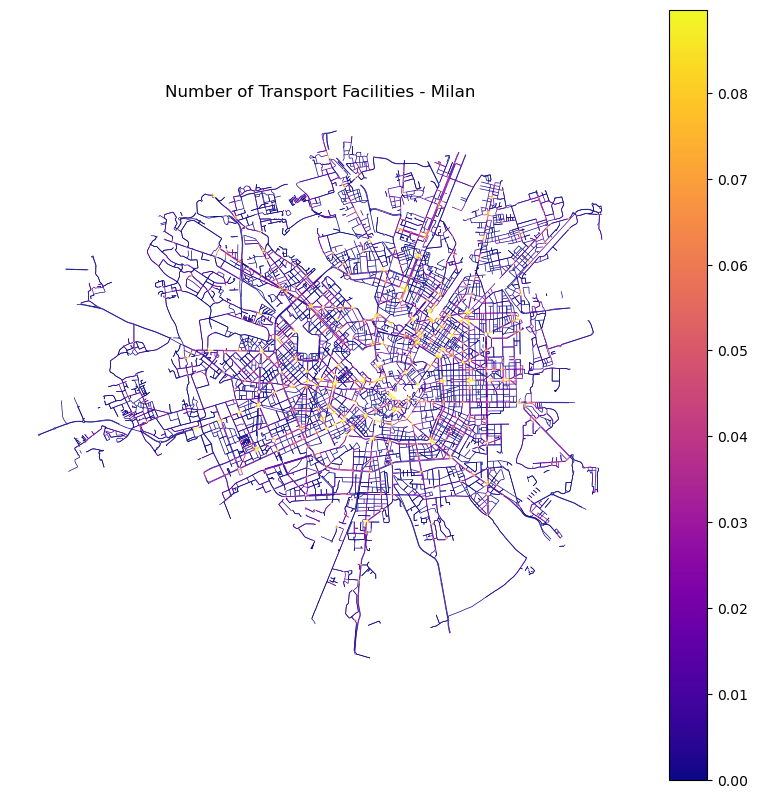

In [18]:
ax = osm_roads_transport.plot(column='transport_count', cmap='plasma', linewidth=0.5, legend=True, figsize=(10, 10))
ax.set_title('Number of Transport Facilities - Milan')
ax.set_axis_off()

## Count POIs per segment

In [19]:
pois_join = gpd.sjoin(pois_filtered, buffered_50, how="left", predicate="within")
pois_count = pois_join.groupby('index_right').size().rename('pois_count')
pois_count

index_right
2.0        2
6.0        2
7.0        2
8.0        1
10.0       1
          ..
22158.0    3
22159.0    5
22160.0    3
22162.0    4
22163.0    5
Name: pois_count, Length: 11490, dtype: int64

In [20]:
osm_roads_pois = osm_roads.join(pois_count)
osm_roads_pois['pois_count'] = osm_roads_pois['pois_count'].fillna(0) / osm_roads_pois['length']
q99 = osm_roads_pois['pois_count'].quantile(0.99)
osm_roads_pois['pois_count'] = osm_roads_pois['pois_count'].clip(upper=q99)

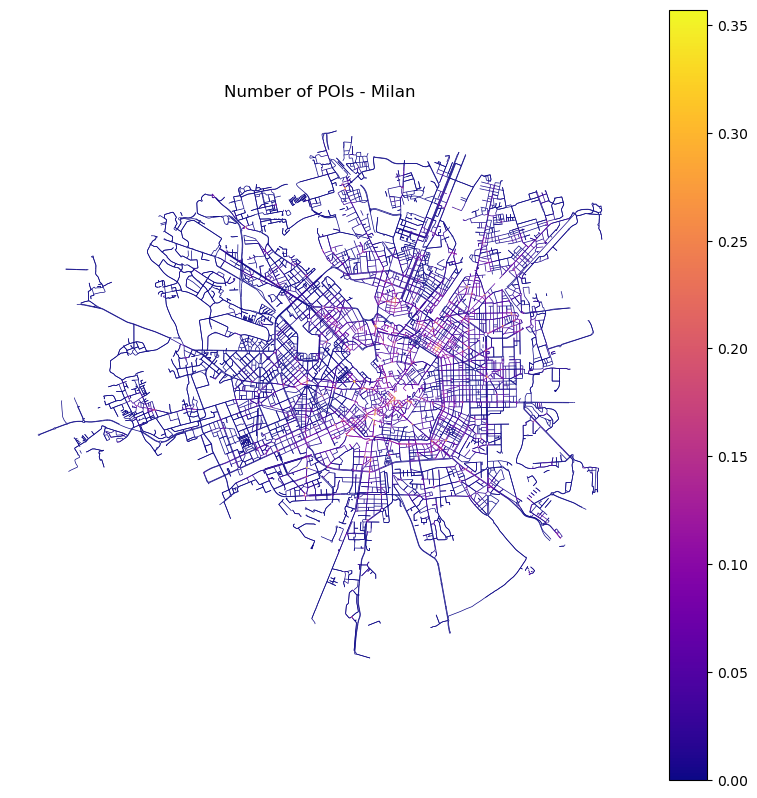

In [21]:
ax = osm_roads_pois.plot(column='pois_count', cmap='plasma', linewidth=0.5, legend=True, figsize=(10, 10))
ax.set_title('Number of POIs - Milan')
ax.set_axis_off()

## Merge and Export

In [22]:
dataset = pd.DataFrame({
    "road_id": osm_roads["segment_id"],
    "signals": osm_roads_sig["signal_count"],
    "transport": osm_roads_transport["transport_count"],
    "pois": osm_roads_pois["pois_count"],
}).fillna(0)
dataset.head()

,road_id,signals,transport,pois
0.0,10371529_743371634_0,0.025901,0.000000,0.000000
1.0,10371529_743371622_0,0.006646,0.000000,0.000000
2.0,10371530_267873043_0,0.001859,0.000930,0.001859
3.0,13595397_271096577_0,0.139212,0.047702,0.000000
4.0,13595397_344814479_0,0.139212,0.000000,0.000000


In [23]:
import os
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)

path = os.path.join(output_dir, "osm_points_features.csv")
dataset.to_csv(path, index=False)
print(f"Exported: {path}")

Exported: data\osm_points_features.csv
